In [1]:
import torch, torchvision
import torch.nn as nn, torch.optim as optim
from torchvision import transforms as T
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt

t = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
trd = DataLoader(torchvision.datasets.CIFAR10('./data',True, transform=t,download=True),64,True)
ted = DataLoader(torchvision.datasets.CIFAR10('./data',False,transform=t,download=True),64)

In [2]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(4096,128), nn.ReLU(), nn.Linear(128,10)
        )
    def forward(self,x): return self.net(x)

def train(model, opt, crit, epochs=5):
    trl,tel,acl = [],[],[]
    for e in range(epochs):
        model.train(); rl=0
        for x,y in trd:
            opt.zero_grad(); o=model(x); l=crit(o,y); l.backward(); opt.step(); rl+=l.item()
        model.eval(); tl=c=n=0
        with torch.no_grad():
            for x,y in ted:
                o=model(x); l=crit(o,y); tl+=l.item(); c+=(o.argmax(1)==y).sum().item(); n+=len(y)
        tr,te,ac = rl/len(trd), tl/len(ted), c/n
        trl.append(tr); tel.append(te); acl.append(ac)
        print(f"E{e+1} | Train {tr:.4f} | Test {te:.4f} | Acc {ac:.2f}")
    return trl,tel,acl

SGD
E1 | Train 1.4703 | Test 1.2131 | Acc 0.57
E2 | Train 1.0555 | Test 0.9888 | Acc 0.65
E3 | Train 0.8711 | Test 0.9467 | Acc 0.68
E4 | Train 0.7358 | Test 0.9188 | Acc 0.68
E5 | Train 0.6146 | Test 0.9629 | Acc 0.68
Adam
E1 | Train 1.2776 | Test 1.0168 | Acc 0.64
E2 | Train 0.9124 | Test 0.9112 | Acc 0.68
E3 | Train 0.7355 | Test 0.8759 | Acc 0.70
E4 | Train 0.5949 | Test 0.9001 | Acc 0.70
E5 | Train 0.4687 | Test 0.9913 | Acc 0.70


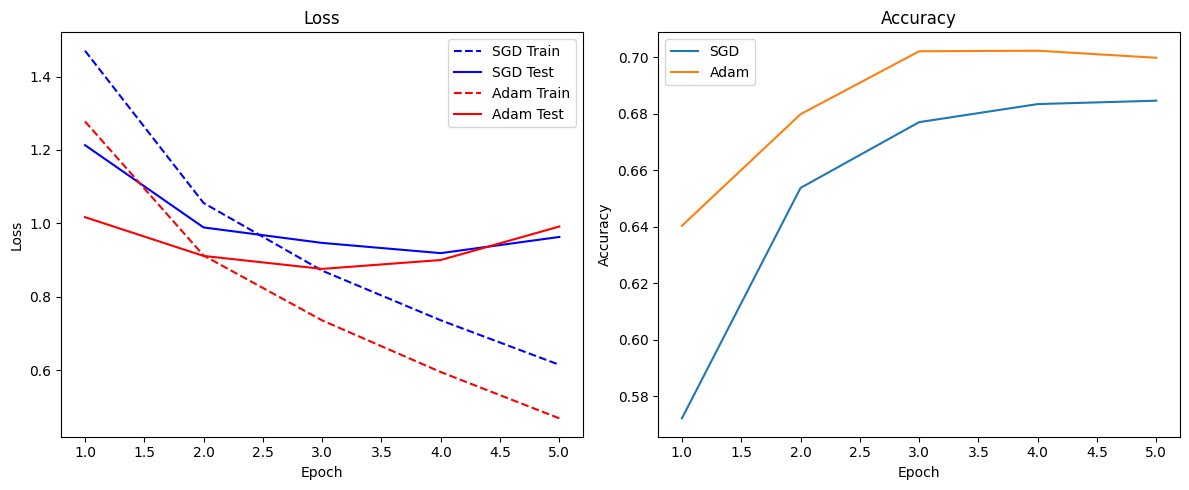

In [3]:
crit = nn.CrossEntropyLoss()
ms,ma = CNN(),CNN()
print("SGD");  trs,tes,acs = train(ms, optim.SGD(ms.parameters(),0.01,momentum=0.9), crit)
print("Adam"); tra,tea,aca = train(ma, optim.Adam(ma.parameters(),1e-3),              crit)

ep = range(1,6)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(ep,trs,'b--',label='SGD Train'); plt.plot(ep,tes,'b-',label='SGD Test')
plt.plot(ep,tra,'r--',label='Adam Train'); plt.plot(ep,tea,'r-',label='Adam Test')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(ep,acs,label='SGD'); plt.plot(ep,aca,label='Adam')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.legend()
plt.tight_layout(); plt.show()